# Per-garden GWAS — mirror Manhattans + QQ, garden by garden

One figure per garden: **mirror Manhattan** on the left (SNP up, non-SNP/SV down, alternating
chromosome shading, dashed line = that class's Bonferroni 0.05/n) and the **QQ for the same
garden** on the right, both classes overlaid with their genomic-inflation λ in the legend.
Layout follows `raw_manhattan_snp_vs_sv_lfmm_tile.ipynb`.

Estimator is **GEMMA v0.98.5 `-lmm 1`** (Wald) per garden, LOCO GRM, 231 founders, rank-inverse-
normalised selection coefficient. There is no cross-garden meta — each panel is an independent
scan (see `METHODS_PERSITE_GWAS.md`).

Vertical dotted line + rotated gene label = a **class-only new peak**: a tiling block whose lead
non-SNP/SV record clears Bonferroni while the lead SNP record *in the same block* does not.

> ⚠️ **Read the λ in each QQ panel with care.** λ near 1.0 does not certify these scans: stratified
> by minor-allele count the *tail* runs 5–60× hot, and ~90% of significant markers sit in the
> lowest-frequency stratum. See `persite_gwas.ipynb` §3 and `mac_calibration.csv`. Peaks below are
> a candidate set, not a calibrated hit list.

In [1]:

import os, sys
import numpy as np, pandas as pd
from scipy import stats
import matplotlib as mpl, matplotlib.pyplot as plt
import matplotlib.lines as mlines
os.chdir("/global/scratch/projects/fc_moilab/tbellg/kmate")
sys.path.insert(0, "analysis/grenenet_selection")
sys.path.insert(0, "analysis/grenenet_selection/blocks")
import lib, blocks_tiling as bt
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

RES = "analysis/grenenet_selection/r3_persite_gwas/results/gemma_gwas_mac12"
PLOTS = f"{RES}/plots"; os.makedirs(PLOTS, exist_ok=True)
CH = ["Chr1", "Chr2", "Chr3", "Chr4", "Chr5"]

def load(name):
    d = np.load(f"{RES}/persite_gwas_{name}.npz", allow_pickle=True)
    chrom = np.array([c.replace("chr", "Chr") for c in d["chrom"].astype(str)])
    pos = d["pos"].astype(np.int64)
    # UNMERGED tiling: fixed by panel LD, so identical across classes -- see builder docstring
    blk = np.asarray(bt.assign_tiling(chrom, pos, r2=0.9), dtype=object)
    return dict(chrom=chrom, pos=pos, P=d["P"], blk=blk,
                sites=[int(s) for s in d["sites"]], bio1=d["bio1"].astype(float))

SNP = load("snp")
sites = SNP["sites"]; bio1 = SNP["bio1"]
site_bio1 = {s: float(b) for s, b in zip(sites, bio1)}
site_order = sorted(sites, key=lambda s: site_bio1[s])          # cold -> hot
GENES = lib.load_genes()

CHROM_LEN = {c: int(SNP["pos"][SNP["chrom"] == c].max()) for c in CH}
OFF, _cum = {}, 0
for c in CH:
    OFF[c] = _cum; _cum += CHROM_LEN[c]
GENOME = _cum

def gpos(chrom, pos):
    return np.array([OFF[c] for c in chrom]) + pos

def genes_on(blk_id, d):
    """Gene symbols overlapping a block's span (+/-2 kb promoter)."""
    m = d["blk"] == blk_id
    if not m.any():
        return []
    ch = d["chrom"][m][0]; lo, hi = d["pos"][m].min() - 2000, d["pos"][m].max() + 2000
    g = GENES[(GENES.chrom.astype(str).str.replace("chr", "Chr") == ch) &
              (GENES.end > lo) & (GENES.start < hi)]
    col = "symbol" if "symbol" in g.columns else g.columns[-1]
    return [str(x) for x in g[col].dropna().unique()[:4]]

print(f"{len(sites)} gardens, bio1 {bio1.min():.1f}-{bio1.max():.1f} C; "
      f"snp {len(SNP['pos']):,} markers")


30 gardens, bio1 6.0-21.6 C; snp 1,111,228 markers


In [2]:

def lam_gc(p):
    p = np.clip(np.asarray(p, float), 1e-300, 1.0)
    p = p[np.isfinite(p)]
    return float(np.median(stats.chi2.isf(p, 1)) / stats.chi2.isf(0.5, 1))

def qq_xy(p, keep_head=8000, n_bulk=2500):
    """Observed vs expected -log10p; keep the whole significant tail, thin the dense bulk."""
    p = np.sort(np.clip(np.asarray(p, float)[np.isfinite(p)], 1e-300, 1.0))
    n = len(p)
    exp = -np.log10((np.arange(n) + 0.5) / n); obs = -np.log10(p)
    if n <= keep_head + n_bulk:
        idx = np.arange(n)
    else:
        idx = np.concatenate([np.arange(keep_head),
                              np.unique(np.geomspace(keep_head, n - 1, n_bulk).astype(int))])
    return exp[idx], obs[idx]

def leads(d, si):
    """Per block, the record with the smallest p in garden si. Returns DataFrame."""
    p = d["P"][:, si]
    ok = np.isfinite(p)
    df = pd.DataFrame(dict(blk=d["blk"][ok], chrom=d["chrom"][ok], pos=d["pos"][ok],
                           nlp=-np.log10(np.clip(p[ok], 1e-300, 1))))
    return df.loc[df.groupby("blk")["nlp"].idxmax()]

def new_peaks(cd, si, snp_lead=None):
    """Blocks whose CLASS lead clears Bonferroni while the SNP lead in the SAME block does not."""
    sl = leads(SNP, si) if snp_lead is None else snp_lead
    cl = leads(cd, si)
    bs = -np.log10(0.05 / np.isfinite(SNP["P"][:, si]).sum())
    bc = -np.log10(0.05 / np.isfinite(cd["P"][:, si]).sum())
    m = cl.merge(sl[["blk", "nlp"]], on="blk", how="left", suffixes=("", "_snp"))
    m["nlp_snp"] = m["nlp_snp"].fillna(0.0)
    m["snp_also"] = m["nlp_snp"] > bs
    return m[m["nlp"] > bc].copy(), bs, bc

SNP_DARK, SNP_LIGHT = "#3B3B3B", "#9A9A9A"
CLS_COL = {"nonsnp": ("#C1560F", "#E8A87C"), "sv": ("#2E7D32", "#88C68B")}


## SNP vs nonsnp — all 30 gardens, cold → hot

/tmp/ipykernel_4081791/1640131332.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


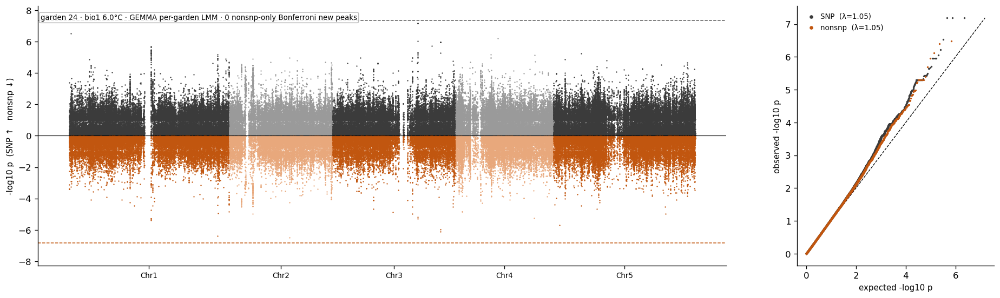

/tmp/ipykernel_4081791/1640131332.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


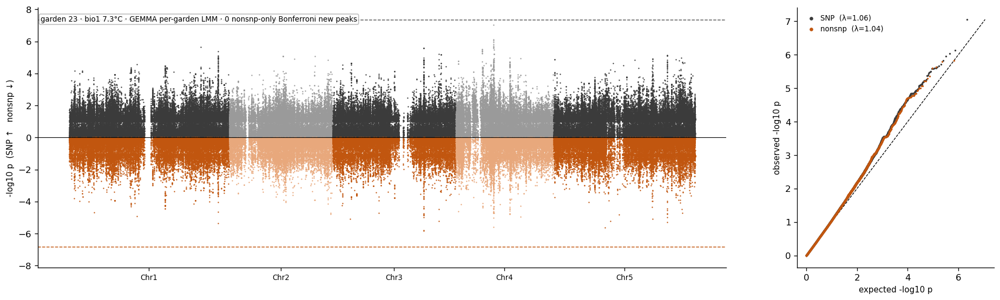

/tmp/ipykernel_4081791/1640131332.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


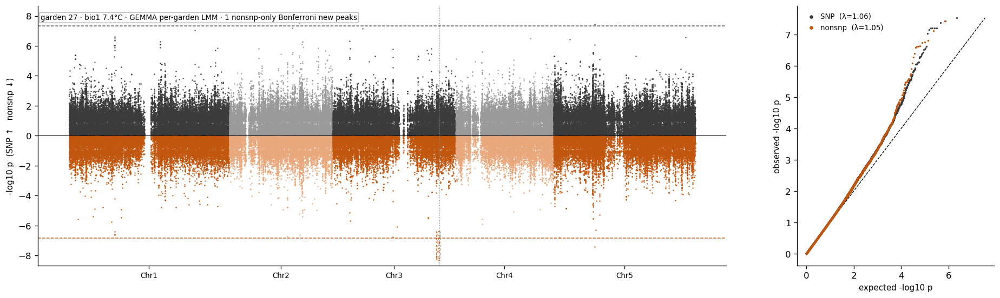

/tmp/ipykernel_4081791/1640131332.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


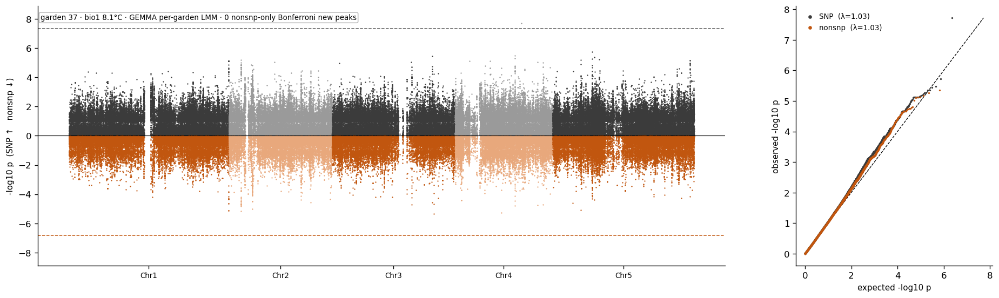

/tmp/ipykernel_4081791/1640131332.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


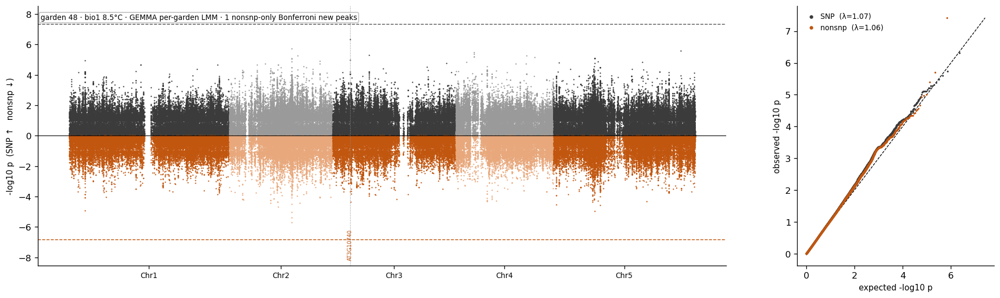

/tmp/ipykernel_4081791/1640131332.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


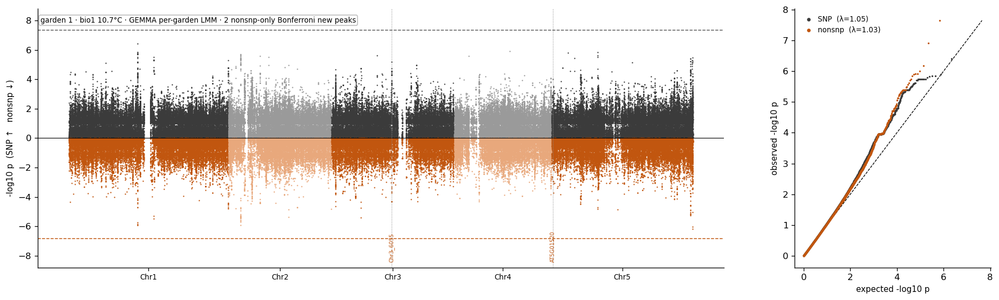

/tmp/ipykernel_4081791/1640131332.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


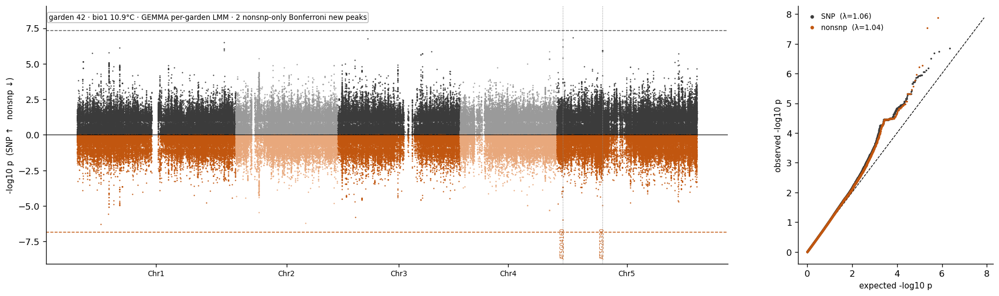

/tmp/ipykernel_4081791/1640131332.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


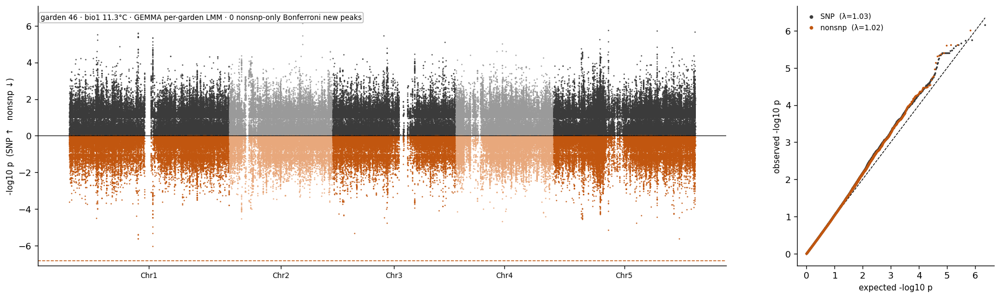

/tmp/ipykernel_4081791/1640131332.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


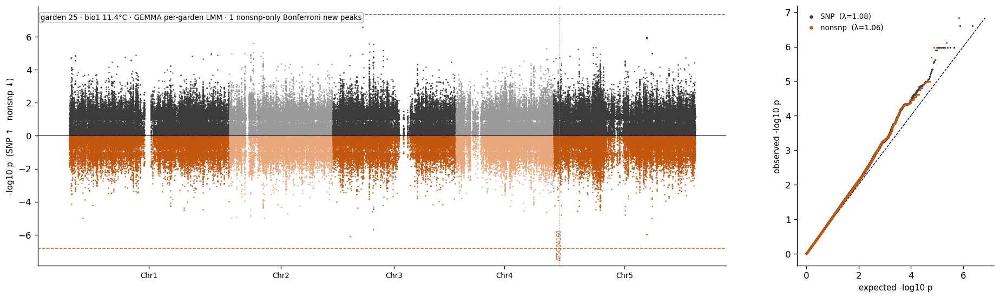

/tmp/ipykernel_4081791/1640131332.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


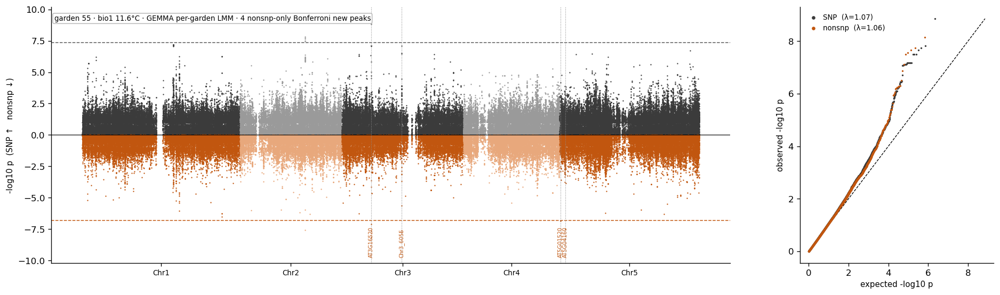

/tmp/ipykernel_4081791/1640131332.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


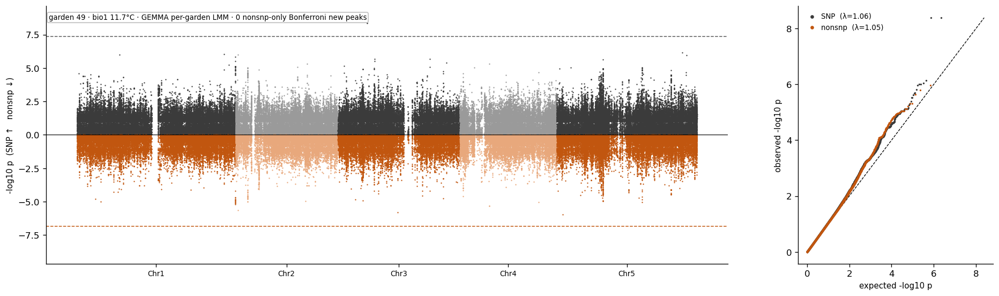

/tmp/ipykernel_4081791/1640131332.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


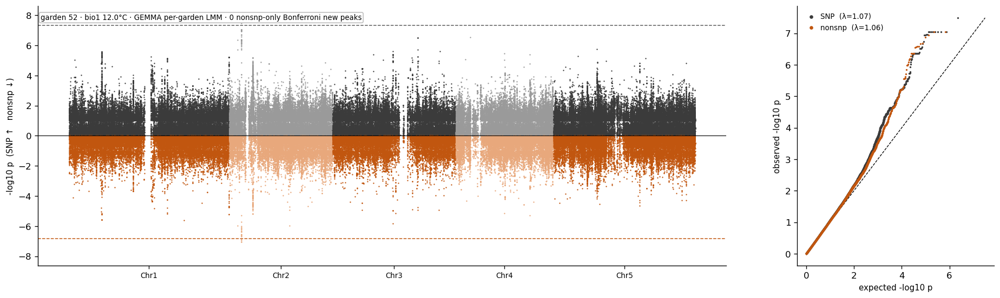

/tmp/ipykernel_4081791/1640131332.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


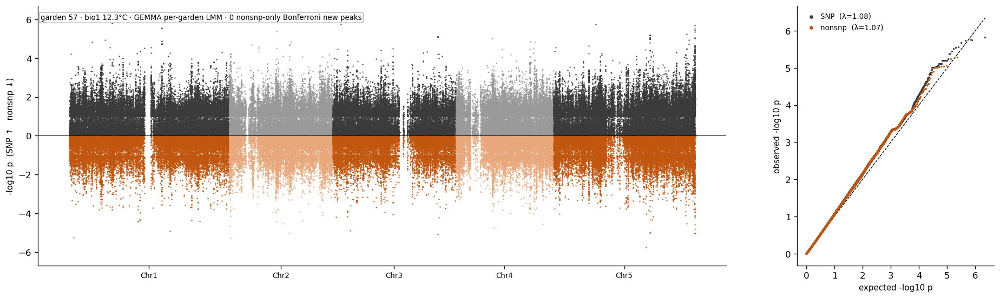

/tmp/ipykernel_4081791/1640131332.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


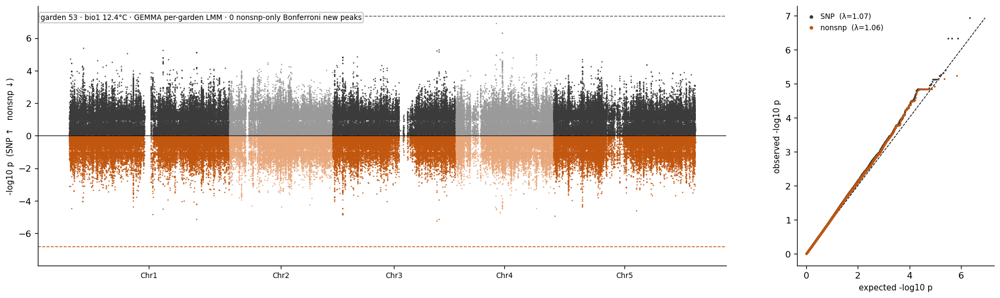

/tmp/ipykernel_4081791/1640131332.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


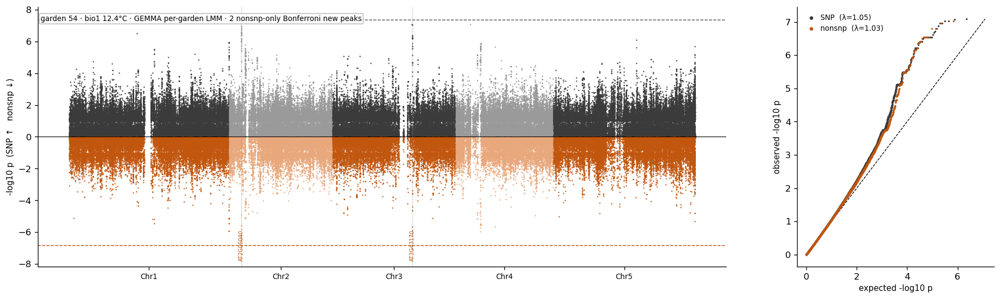

/tmp/ipykernel_4081791/1640131332.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


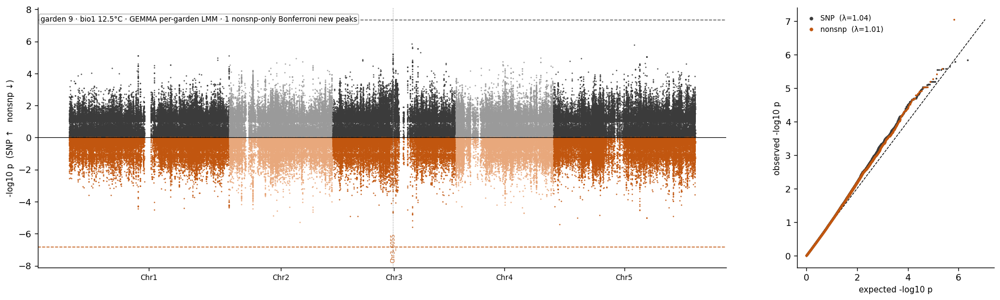

/tmp/ipykernel_4081791/1640131332.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


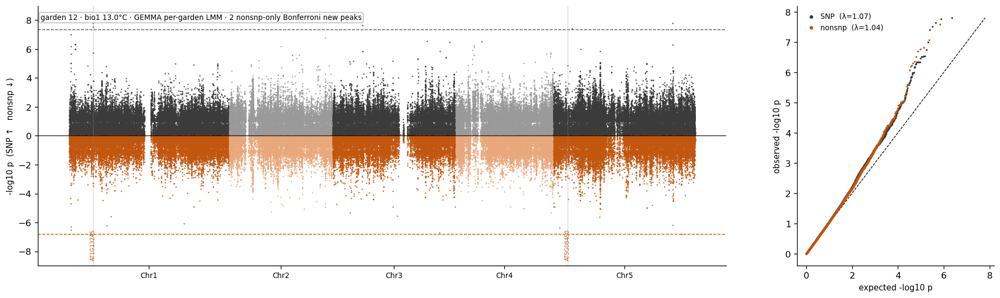

/tmp/ipykernel_4081791/1640131332.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


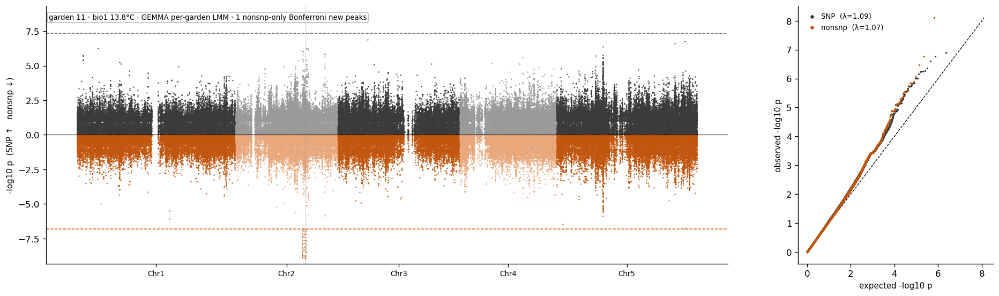

/tmp/ipykernel_4081791/1640131332.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


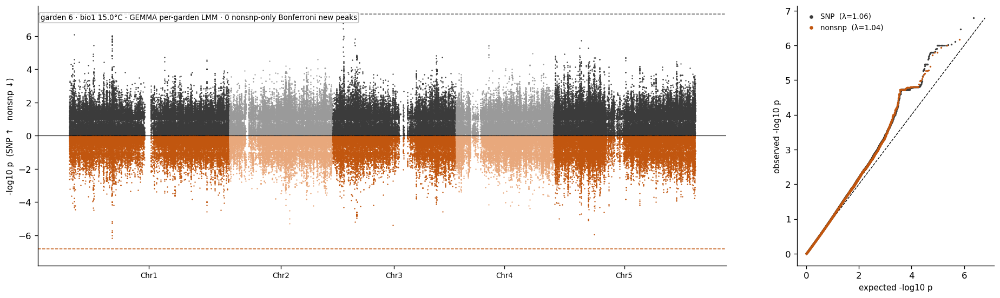

/tmp/ipykernel_4081791/1640131332.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


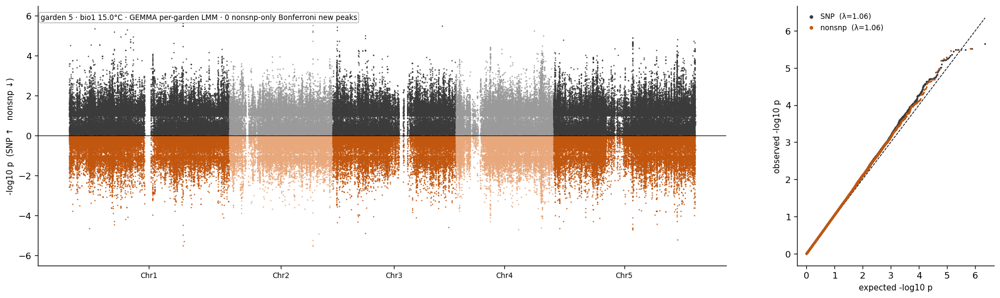

/tmp/ipykernel_4081791/1640131332.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


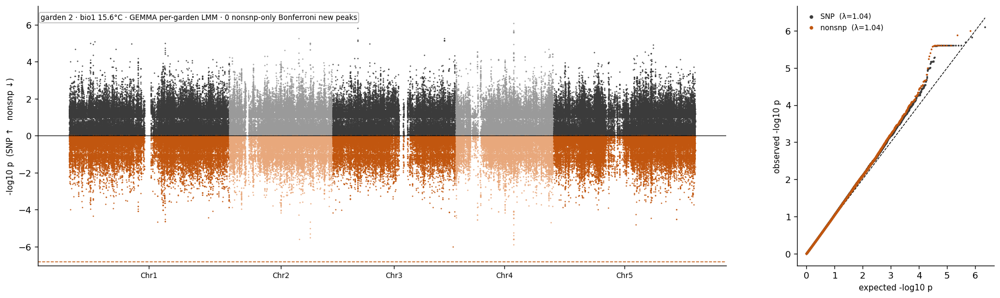

/tmp/ipykernel_4081791/1640131332.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


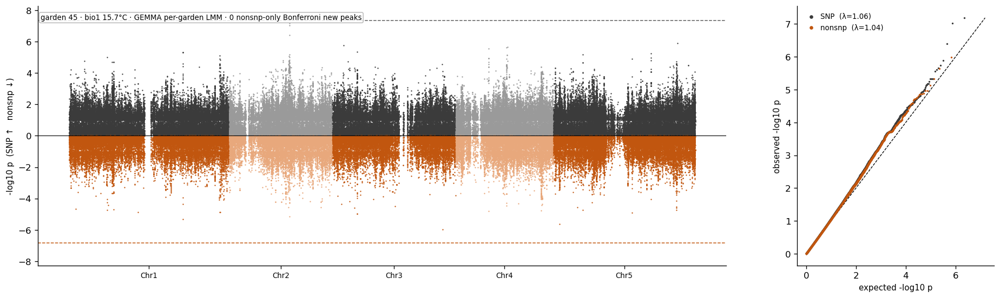

/tmp/ipykernel_4081791/1640131332.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


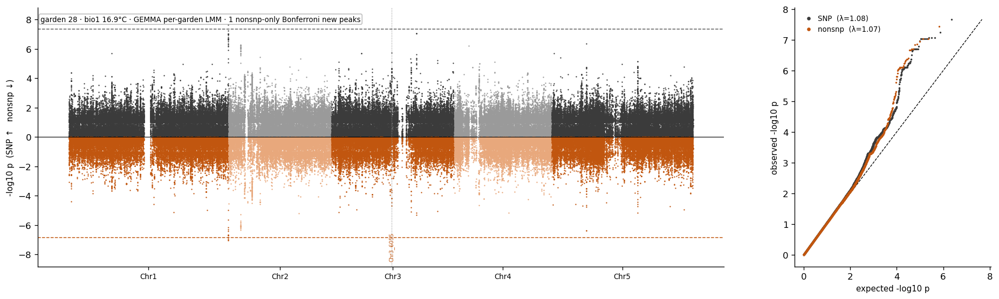

/tmp/ipykernel_4081791/1640131332.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


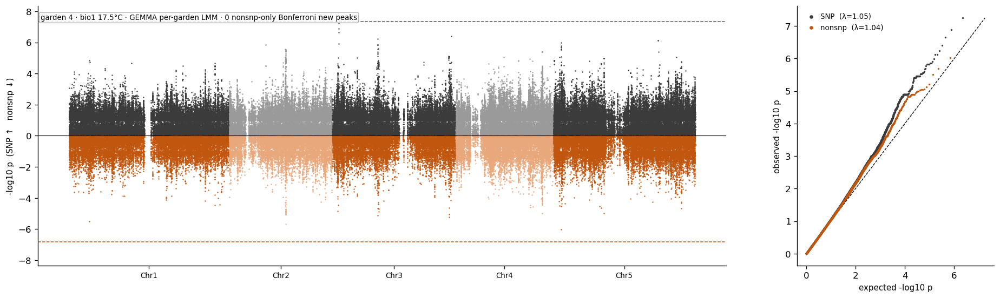

/tmp/ipykernel_4081791/1640131332.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


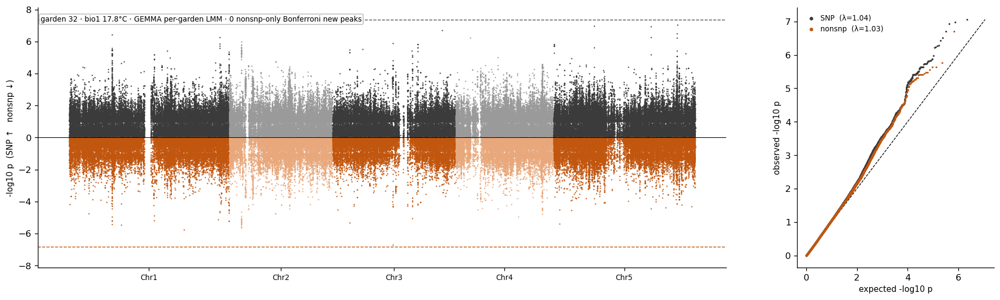

/tmp/ipykernel_4081791/1640131332.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


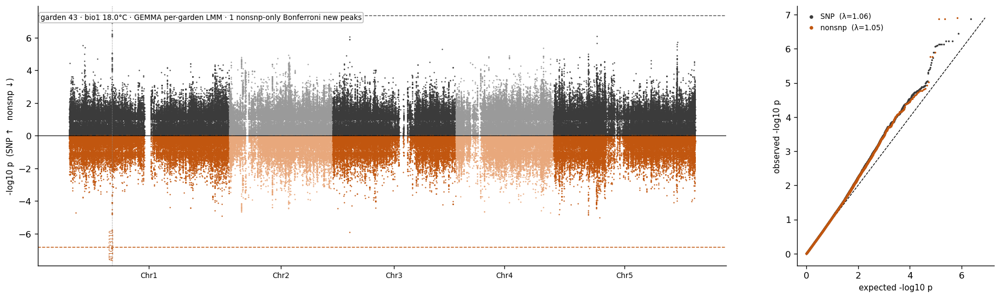

/tmp/ipykernel_4081791/1640131332.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


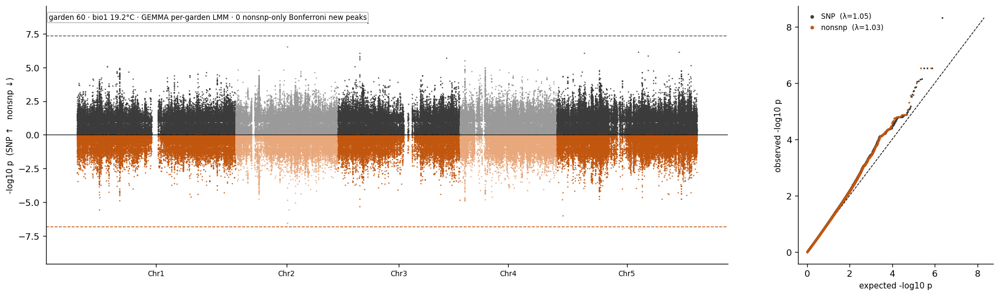

/tmp/ipykernel_4081791/1640131332.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


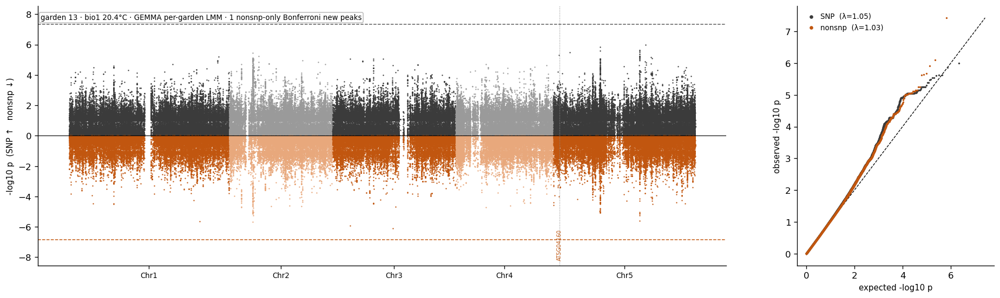

/tmp/ipykernel_4081791/1640131332.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


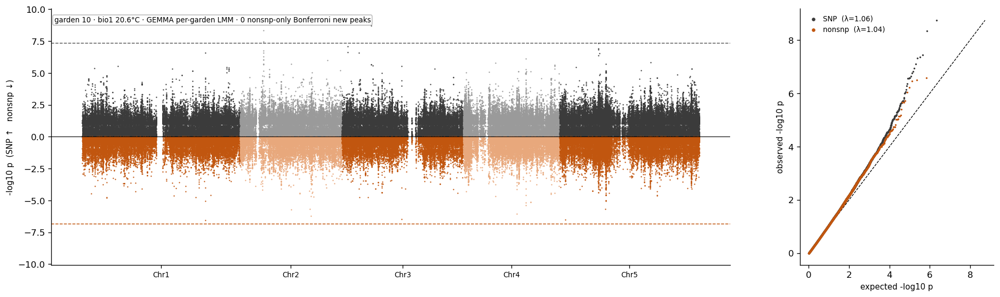

/tmp/ipykernel_4081791/1640131332.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


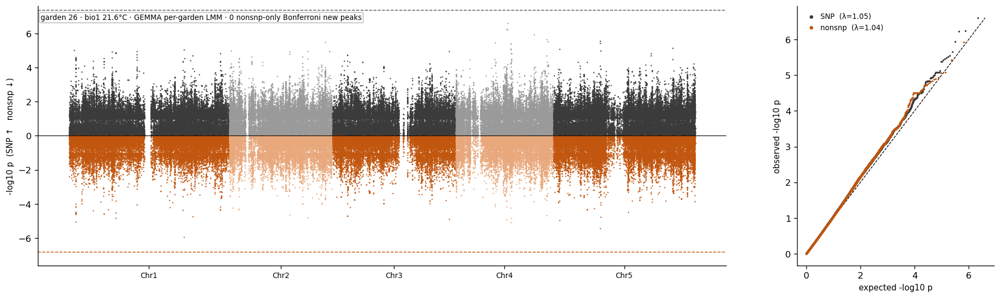

20 nonsnp-only new peaks across 13 gardens


In [3]:

CLS = "nonsnp"
CD = load(CLS)
cdark, clight = CLS_COL[CLS]
rows = []
for s in site_order:
    si = sites.index(s)
    sp, cp = SNP["P"][:, si], CD["P"][:, si]
    npk, bs, bc = new_peaks(CD, si)
    only = npk[~npk.snp_also]

    fig = plt.figure(figsize=(19, 5.2))
    gs = fig.add_gridspec(1, 2, width_ratios=[3.5, 1], wspace=0.16)

    # ---- mirror Manhattan: SNP up, class down ----
    ax = fig.add_subplot(gs[0])
    for i, ch in enumerate(CH):
        ms, mc = SNP["chrom"] == ch, CD["chrom"] == ch
        ns = -np.log10(np.clip(sp[ms], 1e-300, 1)); nc = -np.log10(np.clip(cp[mc], 1e-300, 1))
        xs, xc = gpos(SNP["chrom"][ms], SNP["pos"][ms]), gpos(CD["chrom"][mc], CD["pos"][mc])
        ks = (ns > 1.0) | (np.arange(len(ns)) % 12 == 0)      # thin the null floor only
        kc = (nc > 1.0) | (np.arange(len(nc)) % 4 == 0)
        ax.scatter(xs[ks], ns[ks], s=2, c=(SNP_DARK if i % 2 == 0 else SNP_LIGHT),
                   rasterized=True, linewidths=0)
        ax.scatter(xc[kc], -nc[kc], s=2, c=(cdark if i % 2 == 0 else clight),
                   rasterized=True, linewidths=0)
    ax.axhline(0, c="k", lw=.7)
    ax.axhline(bs, ls="--", c="0.35", lw=.9); ax.axhline(-bc, ls="--", c=cdark, lw=.9)
    ymax = max(np.nanmax(-np.log10(np.clip(sp, 1e-300, 1))),
               np.nanmax(-np.log10(np.clip(cp, 1e-300, 1)))) * 1.15
    for _, r in only.iterrows():
        g = genes_on(r.blk, CD)
        lab = g[0] if g else r.blk
        x = OFF[r.chrom] + r.pos
        ax.axvline(x, ls=":", c="0.55", lw=.7)
        ax.annotate(lab, xy=(x, -ymax * 0.96), ha="center", va="bottom", fontsize=6,
                    color=cdark, rotation=90)
        rows.append(dict(garden=s, bio1=site_bio1[s], blk=r.blk, chrom=r.chrom, pos=int(r.pos),
                         nlp=round(r.nlp, 2), nlp_snp=round(r.nlp_snp, 2), genes=";".join(g)))
    ax.set_ylim(-ymax, ymax)
    ax.set_xticks([OFF[c] + CHROM_LEN[c] / 2 for c in CH]); ax.set_xticklabels(CH, fontsize=8)
    ax.set_ylabel(f"-log10 p  (SNP \u2191   {CLS} \u2193)", fontsize=9)
    ax.annotate(f"garden {s} \u00b7 bio1 {site_bio1[s]:.1f}\u00b0C \u00b7 GEMMA per-garden LMM "
                f"\u00b7 {len(only)} {CLS}-only Bonferroni new peaks",
                xy=(0.004, 0.97), xycoords="axes fraction", va="top", fontsize=8,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="0.7", alpha=.85))
    for sp_ in ["top", "right"]:
        ax.spines[sp_].set_visible(False)

    # ---- QQ, both classes, lambdas in the legend ----
    axq = fig.add_subplot(gs[1])
    xs_, ys_ = qq_xy(sp); xc_, yc_ = qq_xy(cp)
    hi = max(xs_.max(), ys_.max(), xc_.max(), yc_.max())
    axq.plot([0, hi], [0, hi], c="k", lw=.8, ls="--", zorder=1)
    axq.scatter(xs_, ys_, s=4, c=SNP_DARK, rasterized=True, linewidths=0, zorder=2,
                label=f"SNP  (\u03bb={lam_gc(sp):.2f})")
    axq.scatter(xc_, yc_, s=4, c=cdark, rasterized=True, linewidths=0, zorder=2,
                label=f"{CLS}  (\u03bb={lam_gc(cp):.2f})")
    axq.set_xlabel("expected -log10 p", fontsize=9); axq.set_ylabel("observed -log10 p", fontsize=9)
    axq.legend(loc="upper left", frameon=False, fontsize=8, markerscale=2, handletextpad=0.3)
    for sp_ in ["top", "right"]:
        axq.spines[sp_].set_visible(False)

    fig.tight_layout()
    fig.savefig(f"{PLOTS}/manhattan_qq_{CLS}_garden{s}.png", dpi=120, bbox_inches="tight")
    plt.show(); plt.close(fig)

NEW_nonsnp = pd.DataFrame(rows)
NEW_nonsnp.to_csv(f"{RES}/persite_newpeaks_nonsnp.csv", index=False)
print(f"{len(NEW_nonsnp)} {CLS}-only new peaks across {NEW_nonsnp.garden.nunique()} gardens"
      if len(NEW_nonsnp) else f"no {CLS}-only new peaks")


## SNP vs sv — all 30 gardens, cold → hot

/tmp/ipykernel_4081791/4017398012.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


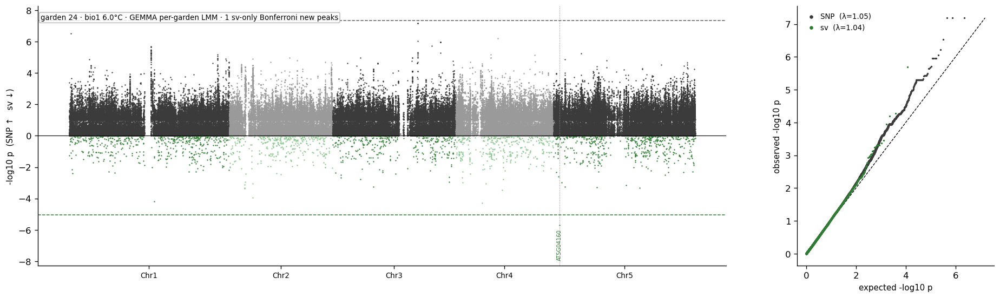

/tmp/ipykernel_4081791/4017398012.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


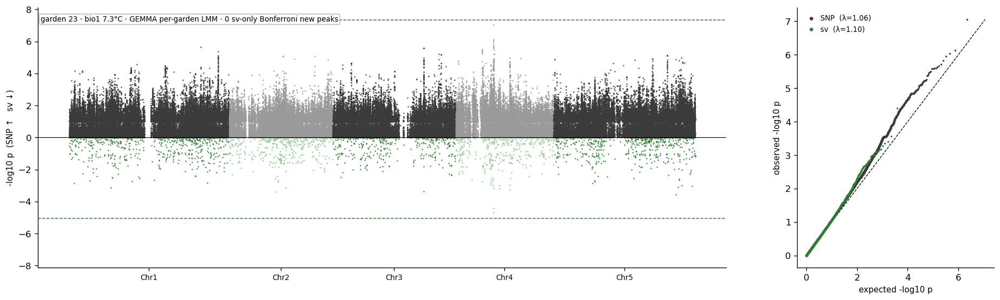

/tmp/ipykernel_4081791/4017398012.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


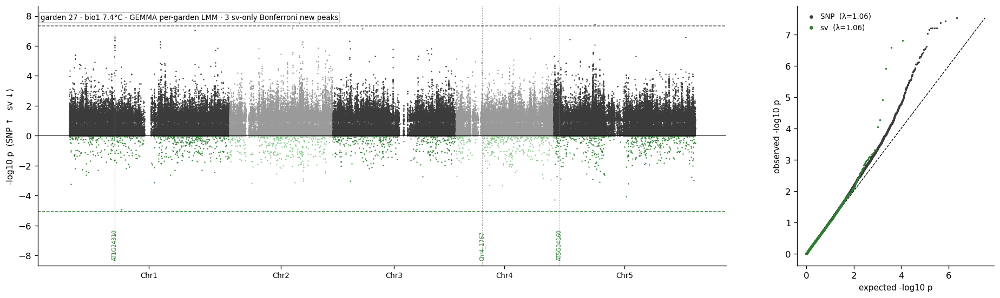

/tmp/ipykernel_4081791/4017398012.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


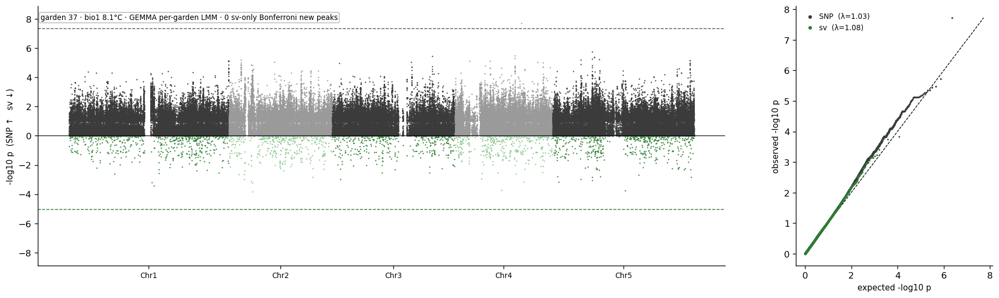

/tmp/ipykernel_4081791/4017398012.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


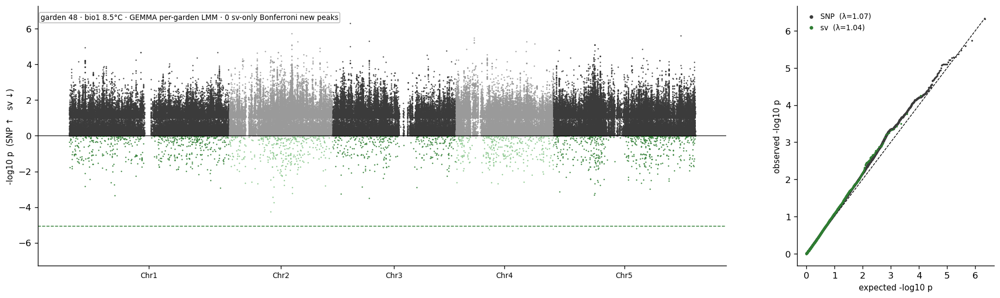

/tmp/ipykernel_4081791/4017398012.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


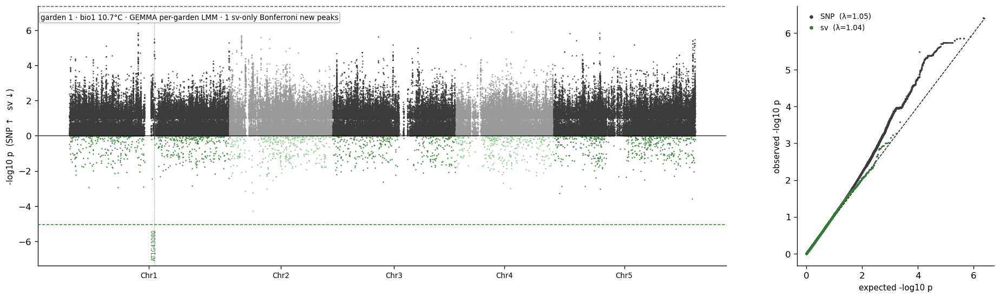

/tmp/ipykernel_4081791/4017398012.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


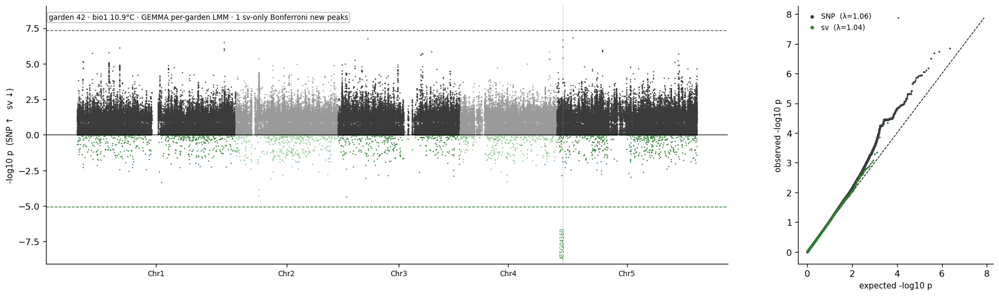

/tmp/ipykernel_4081791/4017398012.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


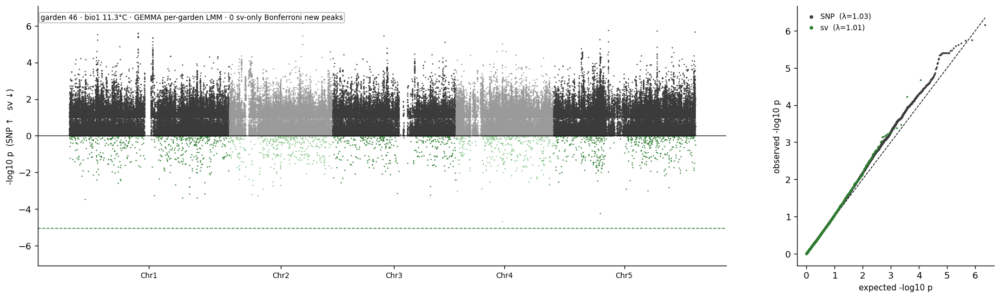

/tmp/ipykernel_4081791/4017398012.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


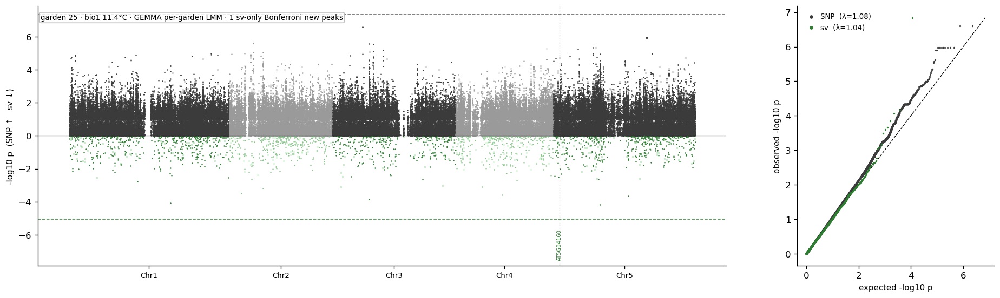

/tmp/ipykernel_4081791/4017398012.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


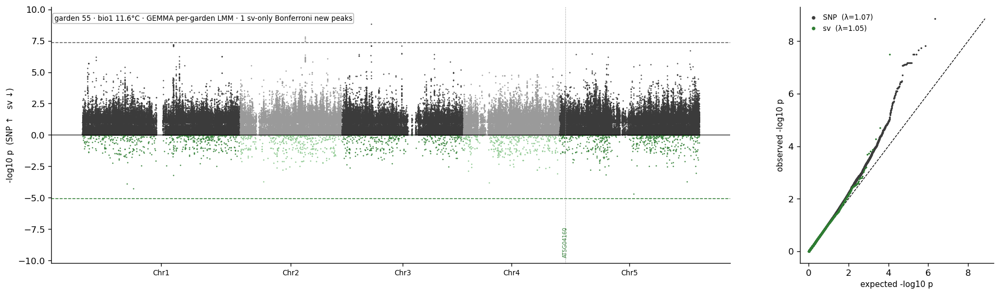

/tmp/ipykernel_4081791/4017398012.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


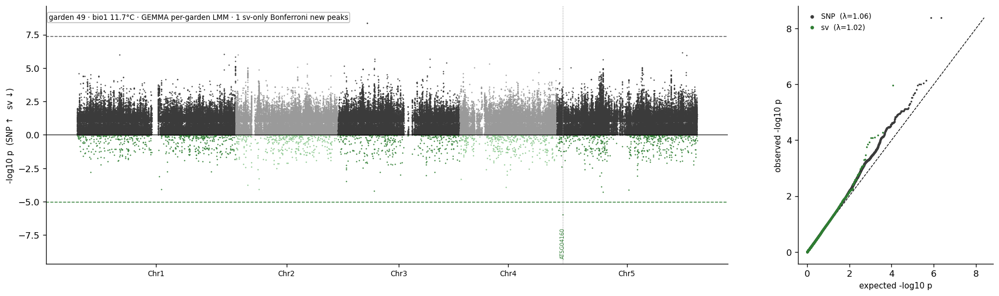

/tmp/ipykernel_4081791/4017398012.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


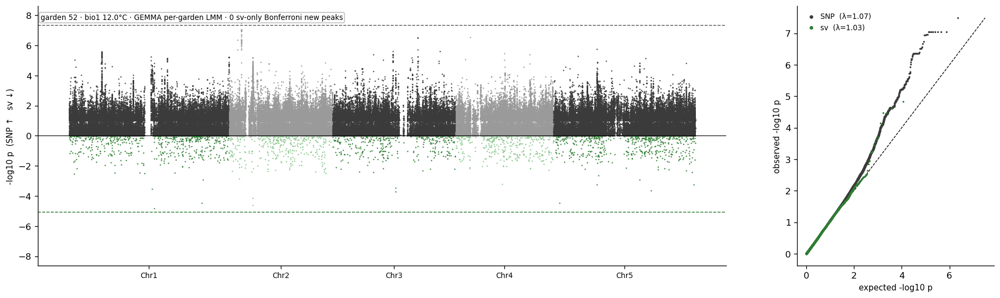

/tmp/ipykernel_4081791/4017398012.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


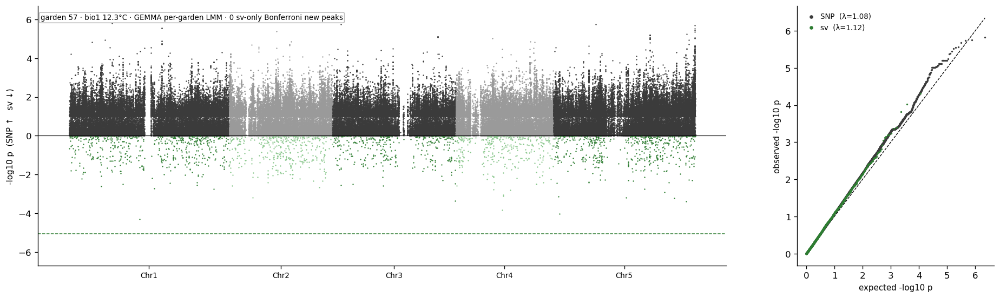

/tmp/ipykernel_4081791/4017398012.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


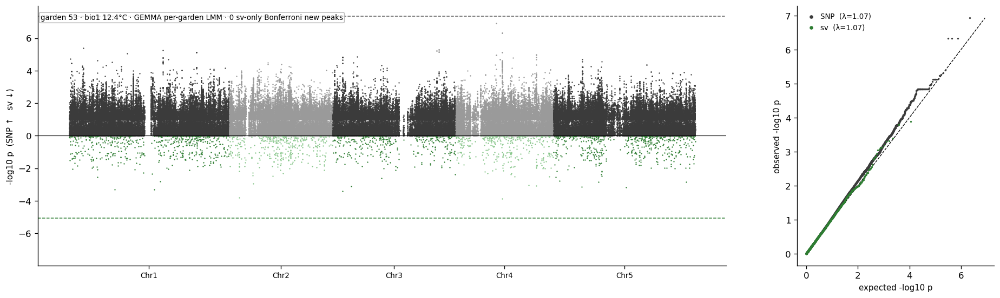

/tmp/ipykernel_4081791/4017398012.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


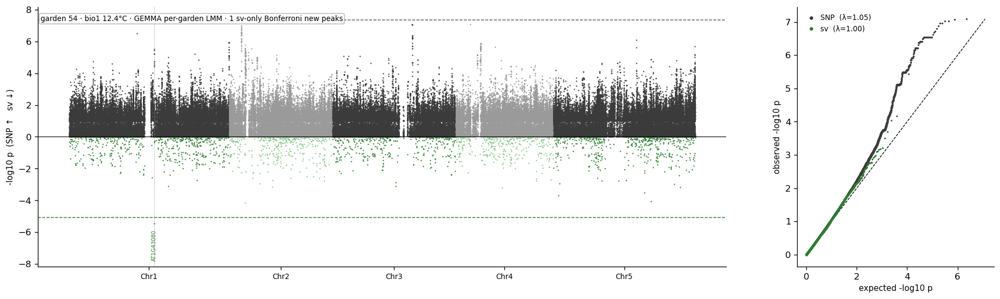

/tmp/ipykernel_4081791/4017398012.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


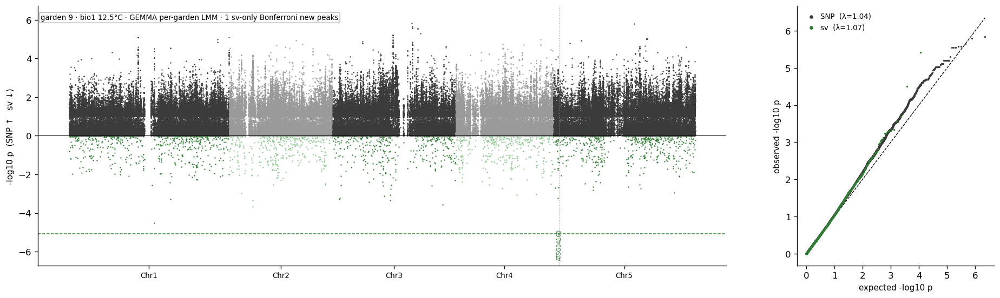

/tmp/ipykernel_4081791/4017398012.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


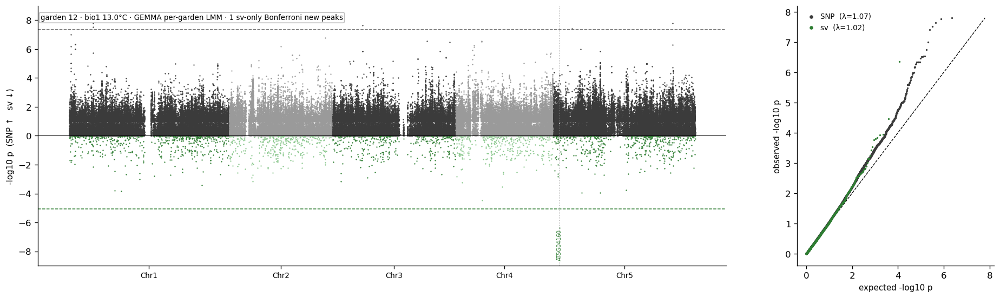

/tmp/ipykernel_4081791/4017398012.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


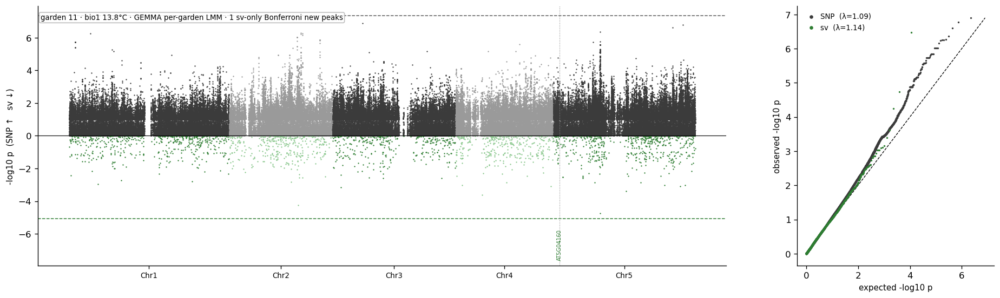

/tmp/ipykernel_4081791/4017398012.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


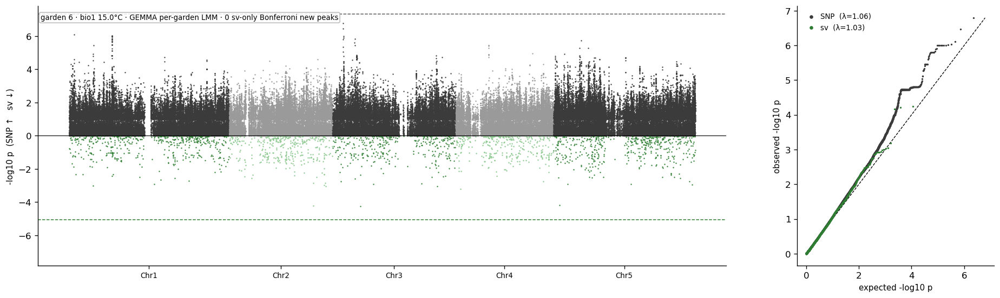

/tmp/ipykernel_4081791/4017398012.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


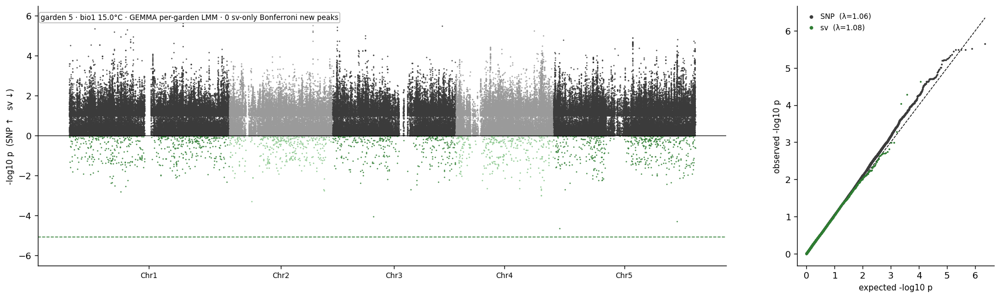

/tmp/ipykernel_4081791/4017398012.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


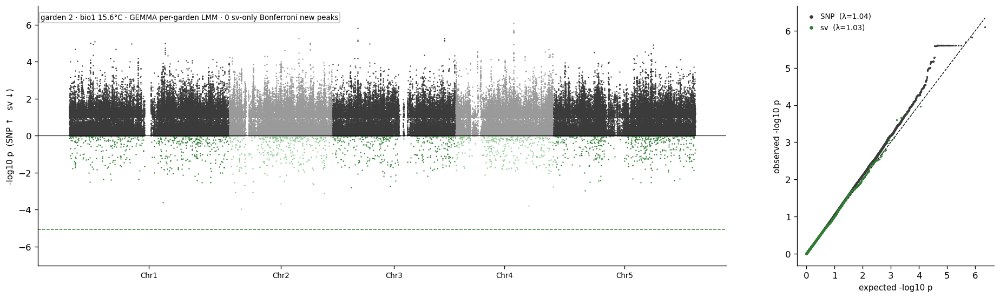

/tmp/ipykernel_4081791/4017398012.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


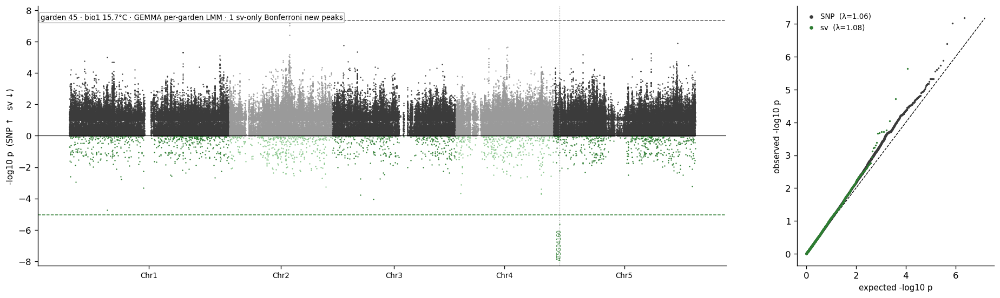

/tmp/ipykernel_4081791/4017398012.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


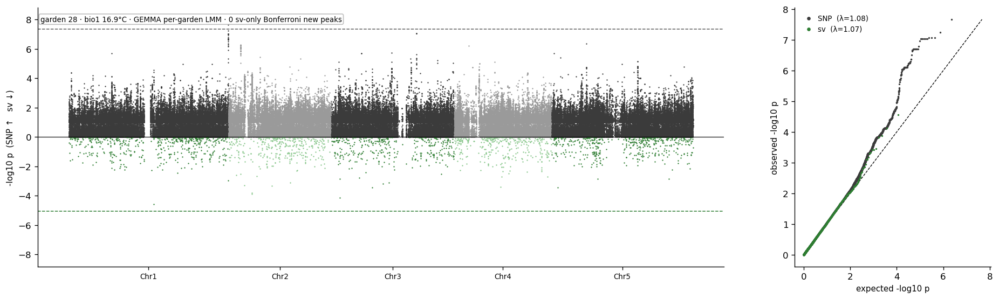

/tmp/ipykernel_4081791/4017398012.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


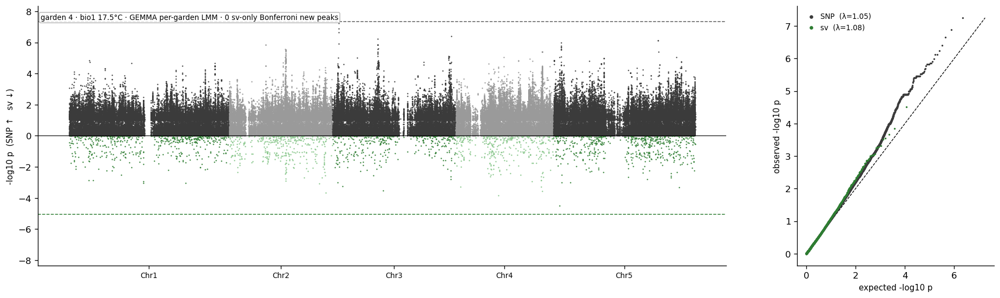

/tmp/ipykernel_4081791/4017398012.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


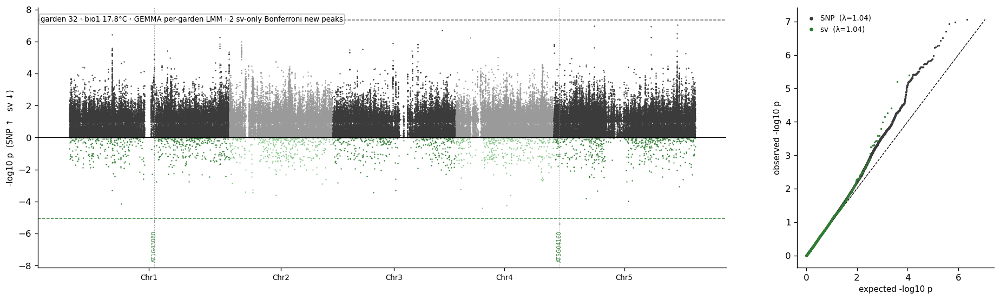

/tmp/ipykernel_4081791/4017398012.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


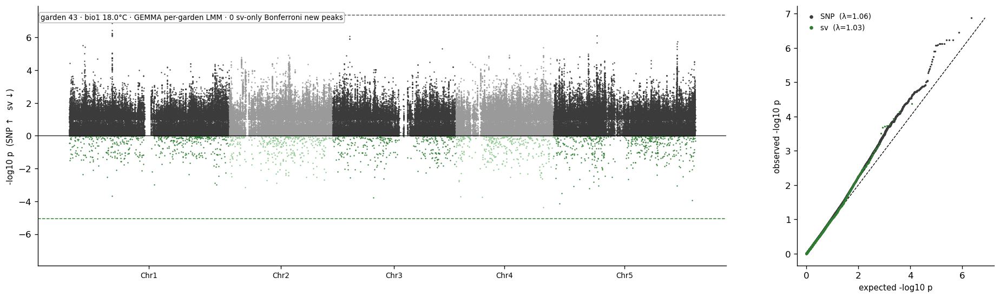

/tmp/ipykernel_4081791/4017398012.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


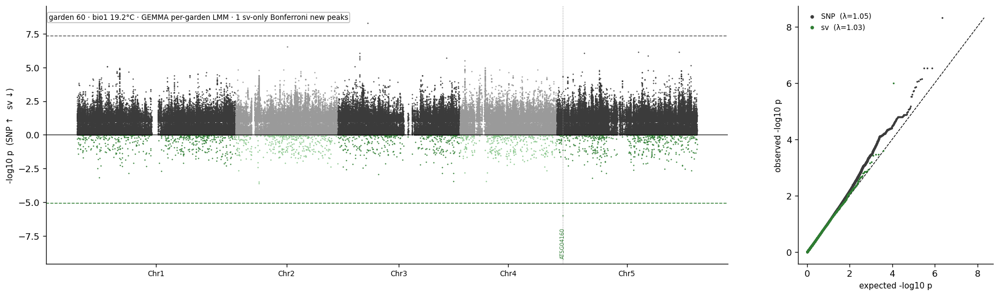

/tmp/ipykernel_4081791/4017398012.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


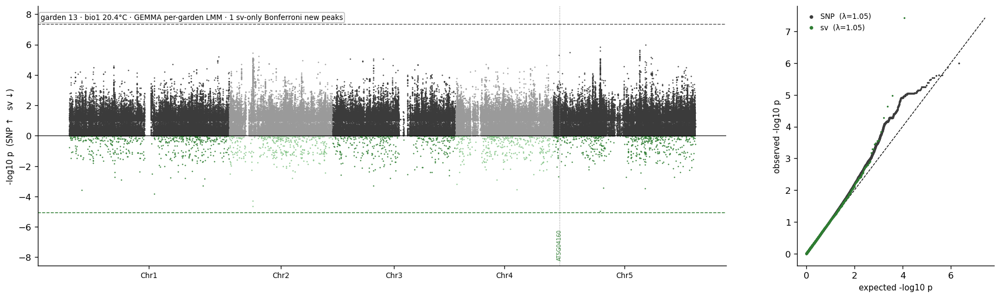

/tmp/ipykernel_4081791/4017398012.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


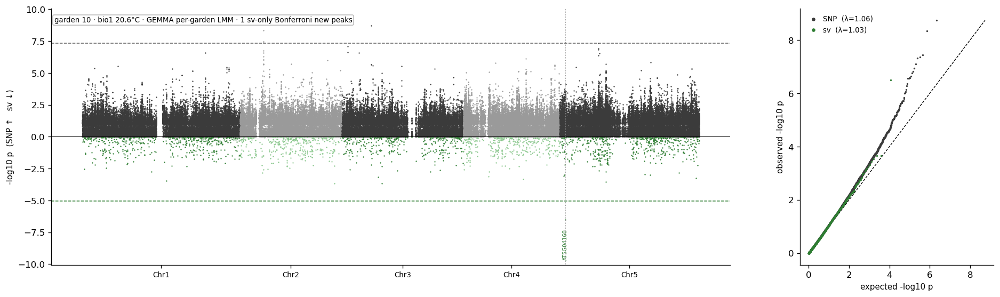

/tmp/ipykernel_4081791/4017398012.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


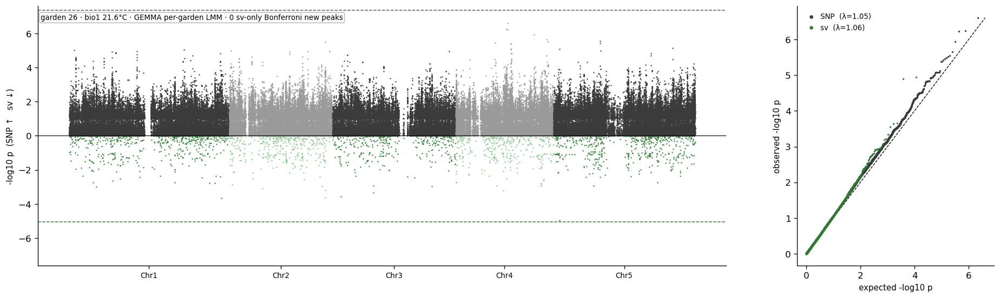

19 sv-only new peaks across 16 gardens


In [4]:

CLS = "sv"
CD = load(CLS)
cdark, clight = CLS_COL[CLS]
rows = []
for s in site_order:
    si = sites.index(s)
    sp, cp = SNP["P"][:, si], CD["P"][:, si]
    npk, bs, bc = new_peaks(CD, si)
    only = npk[~npk.snp_also]

    fig = plt.figure(figsize=(19, 5.2))
    gs = fig.add_gridspec(1, 2, width_ratios=[3.5, 1], wspace=0.16)

    # ---- mirror Manhattan: SNP up, class down ----
    ax = fig.add_subplot(gs[0])
    for i, ch in enumerate(CH):
        ms, mc = SNP["chrom"] == ch, CD["chrom"] == ch
        ns = -np.log10(np.clip(sp[ms], 1e-300, 1)); nc = -np.log10(np.clip(cp[mc], 1e-300, 1))
        xs, xc = gpos(SNP["chrom"][ms], SNP["pos"][ms]), gpos(CD["chrom"][mc], CD["pos"][mc])
        ks = (ns > 1.0) | (np.arange(len(ns)) % 12 == 0)      # thin the null floor only
        kc = (nc > 1.0) | (np.arange(len(nc)) % 4 == 0)
        ax.scatter(xs[ks], ns[ks], s=2, c=(SNP_DARK if i % 2 == 0 else SNP_LIGHT),
                   rasterized=True, linewidths=0)
        ax.scatter(xc[kc], -nc[kc], s=2, c=(cdark if i % 2 == 0 else clight),
                   rasterized=True, linewidths=0)
    ax.axhline(0, c="k", lw=.7)
    ax.axhline(bs, ls="--", c="0.35", lw=.9); ax.axhline(-bc, ls="--", c=cdark, lw=.9)
    ymax = max(np.nanmax(-np.log10(np.clip(sp, 1e-300, 1))),
               np.nanmax(-np.log10(np.clip(cp, 1e-300, 1)))) * 1.15
    for _, r in only.iterrows():
        g = genes_on(r.blk, CD)
        lab = g[0] if g else r.blk
        x = OFF[r.chrom] + r.pos
        ax.axvline(x, ls=":", c="0.55", lw=.7)
        ax.annotate(lab, xy=(x, -ymax * 0.96), ha="center", va="bottom", fontsize=6,
                    color=cdark, rotation=90)
        rows.append(dict(garden=s, bio1=site_bio1[s], blk=r.blk, chrom=r.chrom, pos=int(r.pos),
                         nlp=round(r.nlp, 2), nlp_snp=round(r.nlp_snp, 2), genes=";".join(g)))
    ax.set_ylim(-ymax, ymax)
    ax.set_xticks([OFF[c] + CHROM_LEN[c] / 2 for c in CH]); ax.set_xticklabels(CH, fontsize=8)
    ax.set_ylabel(f"-log10 p  (SNP \u2191   {CLS} \u2193)", fontsize=9)
    ax.annotate(f"garden {s} \u00b7 bio1 {site_bio1[s]:.1f}\u00b0C \u00b7 GEMMA per-garden LMM "
                f"\u00b7 {len(only)} {CLS}-only Bonferroni new peaks",
                xy=(0.004, 0.97), xycoords="axes fraction", va="top", fontsize=8,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="0.7", alpha=.85))
    for sp_ in ["top", "right"]:
        ax.spines[sp_].set_visible(False)

    # ---- QQ, both classes, lambdas in the legend ----
    axq = fig.add_subplot(gs[1])
    xs_, ys_ = qq_xy(sp); xc_, yc_ = qq_xy(cp)
    hi = max(xs_.max(), ys_.max(), xc_.max(), yc_.max())
    axq.plot([0, hi], [0, hi], c="k", lw=.8, ls="--", zorder=1)
    axq.scatter(xs_, ys_, s=4, c=SNP_DARK, rasterized=True, linewidths=0, zorder=2,
                label=f"SNP  (\u03bb={lam_gc(sp):.2f})")
    axq.scatter(xc_, yc_, s=4, c=cdark, rasterized=True, linewidths=0, zorder=2,
                label=f"{CLS}  (\u03bb={lam_gc(cp):.2f})")
    axq.set_xlabel("expected -log10 p", fontsize=9); axq.set_ylabel("observed -log10 p", fontsize=9)
    axq.legend(loc="upper left", frameon=False, fontsize=8, markerscale=2, handletextpad=0.3)
    for sp_ in ["top", "right"]:
        axq.spines[sp_].set_visible(False)

    fig.tight_layout()
    fig.savefig(f"{PLOTS}/manhattan_qq_{CLS}_garden{s}.png", dpi=120, bbox_inches="tight")
    plt.show(); plt.close(fig)

NEW_sv = pd.DataFrame(rows)
NEW_sv.to_csv(f"{RES}/persite_newpeaks_sv.csv", index=False)
print(f"{len(NEW_sv)} {CLS}-only new peaks across {NEW_sv.garden.nunique()} gardens"
      if len(NEW_sv) else f"no {CLS}-only new peaks")
